In [1]:
# install packages
# !pip install missingno
# !pip install openpyxl
# !pip install semanticscholar

# About Dataset

- Dataset Description: ArXiv Scientific Research Papers Dataset

This dataset is a curated collection of research papers from arXiv, covering various scientific fields such as Artificial Intelligence, Machine Learning, computer science, mathematics and more. It includes titles, abstracts, categories, authors, publications and Updated dates making it useful for various machine learning and NLP tasks. It can be used for several use cases given below

- Research Paper Classification – Train a model to predict a paper’s category based on its title or abstract.
- Recommendation Systems – Suggest similar papers based on textual content or categories.
- Trend Analysis – Analyze how research topics evolve.
- Text Summarization – Develop models to generate concise summaries of scientific papers.
- Topic Modeling – Identify hidden themes and emerging research areas.
- Author Impact Analysis – Track contributions and collaborations across different domains.


In [2]:
# import cell
import pandas as pd
import numpy as np
import missingno as msno
import seaborn as sn
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer
from rank_bm25 import BM25Okapi
import warnings
warnings.filterwarnings("ignore")

/opt/anaconda3/envs/Research_Academy/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
data = pd.read_csv("arXiv_scientific dataset.csv")
data

FileNotFoundError: [Errno 2] No such file or directory: 'arXiv_scientific dataset.csv'

In [ ]:
# Show case the dataset information
def data_info(x):
    """
    This function is used to display the dataset information like:
    - shape of dataset
    - Statistical Info
    - Column Datatype
    - Null Value sum
    - Dulplicate values
    ** Parameters: X representing the data
    
    ** Return: None
    """
    print("================================================")
    print("Number of Rows and Columns In the DataSet")
    row, col = x.shape
    print(f"Data_Rows: {row} Data_col: {col}")
    print()
    print("================================================")
    print("Dataset Columns")
    print(x.columns)
    print()
    print("================================================")
    print("Dataset types")
    print(x.dtypes)
    print()
    print("================================================")
    print("DataSet Stats Info")
    print(x.describe())
    print()
    print("================================================")
    print("Dataset Column's Datatype")
    print(x.info())
    print()
    print("================================================")
    print("Dataset Null Count")
    print(x.isna().sum())
    print()
    print("================================================")
    print("Dataset Duplicated Values")
    print(x.duplicated().unique())
    print()
    print("================================================")
    print("Display All the Missing Values In a Chart")
    print(msno.bar(x))
        
    return None

In [ ]:
# call the Function
data_info(data)

# Data Cleaning Section

In [ ]:
# pd.set_option("display.max_colwidth", None)

In [ ]:
# data.head(5)

In [ ]:
# data.tail(5)

In [ ]:
# data.sample(5)

In [ ]:
data['id'].nunique()

In [ ]:
# change the datetime of the columns
# changing the datatype of the time column
def time_change(df, col=["published_date","updated_date"]):
    df[col] = df[col].apply(pd.to_datetime)
    return df
time_change(data)

In [ ]:
# Rename the headers
data.rename(columns={"id":"ID", "title":"Title", "category":"Category", "category_code":"Category Code",
                      "published_date":"Published Date","updated_date":"Updated Date", "authors":"Authors",
                    "first_author":"First Author", "summary":"Summary", "summary_word_count":"Summary Word Count"},inplace=True)

In [ ]:
data.columns

In [ ]:
# Display all the Title in the data
for job in data['Category'].value_counts():
    print(job)

In [ ]:
# Display all the Title in the data
for category in data['Category'].unique():
    print(category)

In [ ]:
# capitalizing the dataset
def capital_letter(df, col=["Title", "Category"]):
    df[col] = df[col].apply(lambda c: c.str.title())
    return df
capital_letter(data)

In [ ]:
data['Category Code'].unique()

In [ ]:
def remove_char(df, col="Authors", col2="First Author"):
    pattern = r"[\r\*\-\(\)]"
    df[["Authors", "First Author"]] = df[["Authors", "First Author"]].apply(
        lambda s: s.str.replace(pattern, "", regex=True))
    return df
remove_char(data)

In [ ]:
def remove_char(df, col="Summary"):
    pattern = r"[\r\*\-\(\)]"
    df["Summary"] = df["Summary"].str.replace(pattern, "", regex=True)
    return df
remove_char(data)

In [ ]:
def remove_char(df, columns=["Authors", "First Author"]):
    pattern = r"[\r\*\-\(\)]"
    df[columns] = df[columns].replace(pattern, "", regex=True)
    return df
remove_char(data)

In [ ]:
data.dtypes

In [ ]:
# Extract the time columns
# separating the the datetime column into year, month, date and hour
data['Published_Date_year'] = data['Published Date'].dt.year
data['Published_Date_year_Month'] = data['Published Date'].dt.month
data['Published_Date_Date'] = data['Published Date'].dt.day

In [ ]:
data

In [ ]:
# Extract the time columns
# separating the the datetime column into year, month, date and hour
data['Updated_Date_year'] = data['Updated Date'].dt.year
data['Updated_Date_Month'] = data['Updated Date'].dt.month
data['Updated_Date'] = data['Updated Date'].dt.day

In [ ]:
# data.drop(columns=['Updated_Date_Date'], inplace=True)

In [ ]:
data

In [ ]:
data['Authors'].unique()

In [ ]:
# save Data as Excel file
# data.to_excel('Research paper.xlsx', index=False)

In [ ]:
# save Data as csv file
# data.to_csv('Research paper csv.csv', index=False)

In [ ]:
# Configuration
WEIGHTS = {
    "similarity": .45,
    "recency": .25,
    "author_score": .15,
    "summary_depth": .10,
    "update_bonus": .05,
}
EMBEDDING_MODEL = "all-MiniLM-L6-v2"
TOP_K_RESULTS = 10
TOP_N_RECS = 5

In [ ]:
# Data Loading & Cleaning
def load_and_clean(path: str) -> pd.DataFrame:
    """
    Load the dataset and ensure date columns are parsed correctly.
    Handles the existing date columns in the data
    """
    df = pd.read_csv(path)

    # Parse the main Date columns (adjust format if needed)
    for col in ["Published Date", "Updated Date"]:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], errors="coerce")

    # Fill any missing 
    df["Summary"] = df["Summary"].fillna("")
    df["Title"] = df["Title"].fillna("")
    df["Authors"] = df["Authors"].fillna("")
    df["First Author"] = df["First Author"].fillna("")

    # Ensure word count column exists
    if "Summary Word Count" not in df.columns:
        df["Summary Word Count"] = df["Summary"].apply(lambda x: len(str(x).split()))

    print(f"Loaded {len(df):,} papers | date range: "
          f"{df['Published Date'].min().date()} → {df['Published Date'].max().date()}")

    return df

In [ ]:
# Feature Engineering
def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Build proxy quality signals from available metadata only
    
    Features:
        recency_score - exponential decay from today's date.
        author_score  - normalised paper count per first author
        summary_depth - normalised word count of abstract
        update_bonus  - papers updated in last 6 months get a boost
        """
    today = datetime.now()

    # Recency score
    # Exponential decay: score = exp(-days / half_life)
    # Papers published today → 1.0 | published 3 years ago → ~0.05
    HALF_LIFE_DAYS = 365
    df["days_since_published"] = (today - df["Published Date"]).dt.days.clip(lower=0)
    df["recency_score"] = np.exp(-df["days_since_published"] / (HALF_LIFE_DAYS / np.log(2)))

    # Author Productivity Score
    # Count how many papers each first author has in the corpus.
    # More papers → higher score (signals active, established researcher).
    author_counts = df["First Author"].value_counts()
    df["author_paper_count"] = df["First Author"].map(author_counts)

    # Summary Depth
    # Longer abstracts tend to be more descriptive and complete
    df["summary_depth"] = df["Summary Word Count"].clip(upper=500)

    # Update bonus
    # Papers updated recently (withing 6 months) are likely still active
    if "Updated Date" in df.columns:
        df["Updated Date"] = pd.to_datetime(df["Updated Date"], errors="coerce")
        cutoff = today - timedelta(days=180)
        df["update_bonus"] = (df["Updated Date"] >= cutoff).astype(float)
    else:
        df["update_bonus"] = .0

    # Normalise all features to [0, 1]
    scaler = MinMaxScaler()
    cols_to_scale = ["recency_score", "author_paper_count", "summary_depth"]
    df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale].fillna(0))

    # Rename for clarity in scoring step
    df.rename(columns={
        "author_paper_count": "author_score",
    }, inplace=True)
    print("Feature Engineering complete.")
    return df
    

In [ ]:
# Semantic Encoding
def build_embeddings(df: pd.DataFrame, model_name: str = EMBEDDING_MODEL):
    """
    Encode each paper's title + summary into a dense vector.
    Returns the model (for query encoding) and the embedding matrix.
    
    The combined text gives richer context than title alone.
    """
    model = SentenceTransformer(model_name)

    # Combine title summary for richer embedding
    texts = (df["Title"]+ ". " + df["Summary"]).tolist()

    print(f"Encoding {len(texts):,} Papers with '{model_name}'...")
    embeddings = model.encode(texts, batch_size=64, show_progress_bar=True,
                             convert_to_numpy=True)
    print(f"Embeddings shape: {embeddings.shape}")
    return model, embeddings

In [ ]:
# Composite Scoring and re-Ranking
def search_and_rerank(
    query: str,
    df:pd.DataFrame,
    embeddings: np.ndarray,
    model:SentenceTransformer,
    weights: dict = WEIGHTS,
    top_k: int = TOP_K_RESULTS,
    category_filter: str = None,
) -> pd.DataFrame:
    """
    Given a free-text query, return the top-k most relevant and high-quality papers.
    
    Steps:
        1. Encode the query into the same embedding space
        2. Compute cosine similarity with all paper embeddings
        3. Build composite score = weighted sum of all signals
        4. Return top-k papers sorted by composite score
        
    Args:
        query:           search string e.g "Deep learning for NLP"
        df:              the feature-engineered dataframe
        embeddings:      (N, D) numpy array of paper embeddings
        model:           loaded sentenceTransformer
        weights:         dict of signal -> weight (must sum to 1)
        top_k:           how many results to return
        category_filter: Optional Category name to restrict results
        
        """
    # Encode Query
    query_embedding = model.encode([query], convert_to_numpy=True) # shape (1,0)

    # Semantic Similarity
    sims = cosine_similarity(query_embedding, embeddings)[0] #shape(N,)

    # Normalise similarity scores to [0,1]
    sim_min, sim_max = sims.min(), sims.max()
    if sim_max > sim_min:
        sims_norm = (sims - sim_min) / (sim_max - sim_min)
    else:
        sims_norm = sims

    # Composite Score
    working = df.copy()
    working["similarity"] = sims_norm

    working["composite_score"] = (
        weights["similarity"]    * working["similarity"] +
        weights["recency"]       * working["recency_score"] +
        weights["author_score"]  * working["author_score"] +
        weights["summary_depth"] * working["summary_depth"] +
        weights["update_bonus"]  * working["update_bonus"]
    )

    # filter by category
    if category_filter:
        mask = (working["Category"].str.contains(category_filter, case=False, na=False) |
                working["Category Code"].str.contains(category_filter, case=False, na=False)
               )
        working = working[mask]

    # sort and return top-k
    results = (
        working
        .sort_values("composite_score", ascending=False)
        .head(top_k)
        [["ID", "Title", "First Author", "Published Date", "Category",
         "composite_score", "similarity", "recency_score", "author_score"]]
        .reset_index(drop=True)
    )
    results.index += 1
    return results

In [ ]:
# Recommendation Engine
def recommend_similar(
    paper_id,
    df:pd.DataFrame,
    embeddings: np.ndarray,
    top_n: int = TOP_N_RECS,
) -> pd.DataFrame:
    """
    Given a paper ID, find the top-N most similar papers.
    Uses Cosine similarity on embeddings (content-based filtering)
    
    Args:
        paper_id       : the ID value of the seed paper
        df             : the dataframe (must have an 'ID' column)
        embeddings     : (N, D) numpy array
        top_n          : number of recommendations
        
        """
    # Find the index of the seed paper
    matches = df.index[df["ID"] == paper_id].tolist()
    if not matches:
        raise ValueError(f"Paper ID '{paper_id}' not found in dataset.")
    idx = matches[0]


    seed_embedding = embeddings[idx].reshape(1, -1) # shape (1, D)
    sims = cosine_similarity(seed_embedding, embeddings)[0]

    # Exclude the seed paper itself
    sims[idx] = -1.0

    top_indices = np.argsort(sims)[::-1][:top_n]

    recommendations = df.iloc[top_indices][
    ["ID", "Title", "First Author", "Published Date", "Category"]
    ].copy()
    recommendations["similarity_score"] = sims[top_indices].round(4)
    recommendations = recommendations.reset_index(drop=True)
    recommendations.index += 1
    return recommendations

In [ ]:
# Evaluation Helpers
def score_breakdown(results: pd.DataFrame) -> None:
    """Pretty-print the score components for the top results."""
    print("\n" + "="*72)
    print(f"{'Rank':<5} {'Title':<45} {'Score':<7} {'Sim':<6} {'Rec':<6} {'Auth':<6}")
    print("="*72)
    for rank, row in results.iterrows():
        title = str(row["Title"])[:43] + ".." if len(str(row["Title"])) > 43 else str(row["Title"])
        print(f"{rank:<5} {title:<45} "
              f"{row['composite_score']:.3f}  "
              f"{row['similarity']:.3f}  "
              f"{row['recency_score']:.3f}  "
              f"{row['author_score']:.3f}")
    print("="*72)

def compare_baseline_vs_reranked(
    query: str,
    df: pd.DataFrame,
    embeddings: np.ndarray,
    model: SentenceTransformer,
    top_k: int = TOP_K_RESULTS,
) ->None:
    """
    Show what a naive date-sorted results looks like vs. the re-ranked output.
    This demonstrates the value of the model clearly.
    """
    print(f"\n{'-'*72}")
    print(f"Query: '{query}'")
    print(f"{'-'*72}")

    # Baseline: Just most recent papers (no relevance check)
    baseline = (
        df.sort_values("Published Date", ascending=False)
        .head(top_k)
        [["Title", "Published Date"]]
        .reset_index(drop=True)
    )
    baseline.index += 1
    print("\n[BASELINE] Most recent papers (ignores relevance):")
    print(baseline.to_string())

    # Re-ranked
    reranked = search_and_rerank(query, df, embeddings, model, top_k=top_k)
    print(f"\n[RE-RANKED] Top-{top_k} by composite Score:")
    score_breakdown(reranked)

In [ ]:
# Loading the dataset
DATASET_PATH = "Research paper csv.csv"

df = load_and_clean(DATASET_PATH)
df = engineer_features(df)

In [ ]:
# # Build embeddings save/load for production
# model, embeddings = build_embeddings(df)
# np.save("paper_embeddings.npy", embeddings)

# # TO reload: embeddings = np.load("paper_embeddings.npy")

In [ ]:
# # Re-rank search results
# query = "deep learning for image classification"
# results = search_and_rerank(query, df, embeddings, model, top_k=10)
# print(f"\nTop 10 results for: '{query}'")
# score_breakdown(results)

In [ ]:
# # Compare Baseline vs re-ranked
# compare_baseline_vs_reranked(query, df, embeddings, model, top_k=10)

In [ ]:
# # Recommend similar papers
# # Use the ID of the top result to find similar papers
# seed_id = results.iloc[0]["ID"]
# recs = recommend_similar(seed_id, df, embeddings, top_n=5)
# print(f"\nPapers similar ro ID={seed_id}:")
# print(recs.to_string())

In [ ]:
# # search with category filter example
# filtered = search_and_rerank(
#     query="Artificial Intelligence",
#     df=df,
#     embeddings = embeddings,
#     model=model,
#     top_k=10,
#     category_filter="cs.AI",
# )
# print(f"\nFiltered Results (cs.AI only):")
# score_breakdown(filtered)

In [ ]:
df

In [ ]:
# metric measure of the model
from rank_bm25 import BM25Okapi

# Use 'Summary' as your text source
corpus = df['Summary'].fillna("").tolist()
tokenized_corpus = [doc.split(" ") for doc in corpus]
bm25_index = BM25Okapi(tokenized_corpus)

def get_bm25_results(query, top_k=10):
    tokenized_query = query.split(" ")
    # Returns the top Summary texts based on keyword frequency
    return bm25_index.get_top_n(tokenized_query, corpus, n=top_k)

In [ ]:
from sentence_transformers import SentenceTransformer

# Load the model specifically for research paper summaries
scientific_model = SentenceTransformer('allenai/specter2_base')

def get_scientific_embeddings(text_list):
    # Use this to encode your 'Summary' column for a better benchmark
    return scientific_model.encode(text_list, show_progress_bar=True)

In [ ]:
from sentence_transformers import util
import torch

def get_pure_semantic_results(query_embedding, dataset_embeddings, top_k=10):
    # This uses only the vector similarity score (0.0 to 1.0)
    cos_scores = util.cos_sim(query_embedding, dataset_embeddings)[0]
    
    # Sort by highest similarity only
    top_results = torch.topk(cos_scores, k=top_k)
    return top_results.indices.tolist()

In [ ]:
import pandas as pd
from rank_bm25 import BM25Okapi
from sentence_transformers import SentenceTransformer, util
import torch

# 1. SETUP MODELS
# Using the same model from your notebook
model = SentenceTransformer('all-MiniLM-L6-v2')

# 2. PREPARE DATA (Using your 'Summary' column)
# Ensure no empty summaries
df['Summary'] = df['Summary'].fillna("No summary available")
documents = df['Summary'].tolist()

# Initialize BM25 Index (The Keyword Baseline)
tokenized_corpus = [doc.split(" ") for doc in documents]
bm25 = BM25Okapi(tokenized_corpus)

# 3. DEFINE THE SEARCH COMPARISON FUNCTION
def run_benchmark(query, top_k=5):
    print(f"--- Results for Query: '{query}' ---\n")
    
    # --- BM25 (Keyword Search) ---
    tokenized_query = query.split(" ")
    bm25_results = bm25.get_top_n(tokenized_query, df.to_dict('records'), n=top_k)
    
    # --- Semantic Search (AI Similarity) ---
    query_embedding = model.encode(query, convert_to_tensor=True)
    # For this test, we re-encode a small batch or use existing ones
    doc_embeddings = model.encode(documents, convert_to_tensor=True) 
    cos_scores = util.cos_sim(query_embedding, doc_embeddings)[0]
    top_results_idx = torch.topk(cos_scores, k=top_k).indices
    
    # 4. DISPLAY RESULTS SIDE-BY-SIDE
    print(f"{'RANK':<5} | {'BM25 (KEYWORDS)':<35} | {'SEMANTIC (AI)':<35}")
    print("-" * 80)
    
    for i in range(top_k):
        bm25_title = bm25_results[i]['Title'][:30] + "..."
        semantic_title = df.iloc[top_results_idx[i].item()]['Title'][:30] + "..."
        print(f"{i+1:<5} | {bm25_title:<35} | {semantic_title:<35}")

# 5. EXECUTE (This is what actually produces the "Result")
run_benchmark("Deep Learning for Medical Imaging")

In [ ]:
def calculate_metrics(predicted_ids, ground_truth_ids):
    hits = set(predicted_ids) & set(ground_truth_ids)
    p = len(hits) / len(predicted_ids) if predicted_ids else 0
    r = len(hits) / len(ground_truth_ids) if ground_truth_ids else 0
    f1 = 2 * (p * r) / (p + r) if (p + r) > 0 else 0
    return {"Precision": p, "Recall": r, "F1": f1}

# EXAMPLE TEST:
ground_truth = [101, 105] 
my_model_output = [101, 202, 303, 404, 505]

results = calculate_metrics(my_model_output, ground_truth)
print("Model Performance Scores:", results)

In [ ]:

import os
import time
import warnings
import numpy as np
import pandas as pd
import torch
import hashlib
import pickle

from rank_bm25 import BM25Okapi
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity as sk_cosine
from sentence_transformers import SentenceTransformer, util
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

warnings.filterwarnings("ignore")
print("All libraries loaded.")


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# SPEED OPTIMIZATION 2: Smart Embedding Cache
# Hashes the corpus text → only re-encodes if data changes
# ─────────────────────────────────────────────────────────────────────────────

EMBED_CACHE_PATH = "embed_cache.pkl"
EMBED_MODEL_NAME  = "all-MiniLM-L6-v2"   # fast, good quality

def get_corpus_hash(texts):
    """Fingerprint the corpus so we know when to invalidate cache."""
    combined = " ".join(texts[:100])   # sample for speed
    return hashlib.md5(combined.encode()).hexdigest()

def load_or_build_embeddings(df, model_name=EMBED_MODEL_NAME, cache_path=EMBED_CACHE_PATH):
    """
    Load cached embeddings if corpus unchanged, else encode and save.
    SPEED GAIN: Saves 2-10 minutes on large datasets on every rerun.
    """
    texts = (df["Title"] + ". " + df["Summary"]).fillna("").tolist()
    corpus_hash = get_corpus_hash(texts)

    # Try loading cache
    if os.path.exists(cache_path):
        with open(cache_path, "rb") as f:
            cache = pickle.load(f)
        if cache.get("hash") == corpus_hash and cache.get("model") == model_name:
            print(f"⚡ Cache HIT — loaded {len(cache['embeddings']):,} embeddings instantly.")
            model = SentenceTransformer(model_name)
            return model, cache["embeddings"]

    # Cache miss → encode
    print(f"Cache MISS — encoding {len(texts):,} papers with '{model_name}'...")
    t0 = time.time()
    model = SentenceTransformer(model_name)

    # SPEED OPTIMIZATION 3: larger batch + normalize in one pass
    embeddings = model.encode(
        texts,
        batch_size=128,          # 2x bigger batch → ~30% faster
        show_progress_bar=True,
        convert_to_numpy=True,
        normalize_embeddings=True,  # pre-normalize → skip division at query time
    )
    elapsed = time.time() - t0
    print(f" Encoded in {elapsed:.1f}s  |  shape: {embeddings.shape}")

    with open(cache_path, "wb") as f:
        pickle.dump({"hash": corpus_hash, "model": model_name, "embeddings": embeddings}, f)
    print("Embeddings cached to disk.")
    return model, embeddings


# ── Load (or build) embeddings ──────────────────────────────────────────────
embed_model, embeddings = load_or_build_embeddings(df)


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# MODEL 1: BM25 — Classic keyword search (baseline)
# ─────────────────────────────────────────────────────────────────────────────
print("Building BM25 index...")
t0 = time.time()
corpus_texts = (df["Title"] + " " + df["Summary"]).fillna("").tolist()
tokenized_corpus = [doc.lower().split() for doc in corpus_texts]
bm25_model = BM25Okapi(tokenized_corpus)
print(f"BM25 ready in {time.time()-t0:.2f}s")

# ─────────────────────────────────────────────────────────────────────────────
# MODEL 2: TF-IDF — Weighted keyword search
# Better than raw BM25 for diverse vocabulary
# ─────────────────────────────────────────────────────────────────────────────
print("\nBuilding TF-IDF index...")
t0 = time.time()
tfidf_vec = TfidfVectorizer(max_features=30_000, ngram_range=(1, 2), sublinear_tf=True)
tfidf_matrix = tfidf_vec.fit_transform(corpus_texts)   # sparse, memory-efficient
print(f"TF-IDF ready in {time.time()-t0:.2f}s  |  vocab: {len(tfidf_vec.vocabulary_):,} terms")

# ─────────────────────────────────────────────────────────────────────────────
# MODEL 3: Pure Semantic (cosine similarity only, no metadata boost)
# Good at meaning, ignores recency / author quality
# ─────────────────────────────────────────────────────────────────────────────
# (uses embeddings already built above)
print("\nPure-Semantic model ready (uses cached embeddings).")

# ─────────────────────────────────────────────────────────────────────────────
# MODEL 4: YOUR Composite Model (semantic + recency + author + summary depth)
# Already defined as search_and_rerank() in the notebook
# ─────────────────────────────────────────────────────────────────────────────
print("Composite model ready (search_and_rerank).")
print("\n All 4 models initialised.")


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# UNIFIED SEARCH — returns top-K paper indices per model
# ─────────────────────────────────────────────────────────────────────────────

def search_bm25(query, top_k=10):
    tokens = query.lower().split()
    scores = bm25_model.get_scores(tokens)
    return np.argsort(scores)[::-1][:top_k].tolist()

def search_tfidf(query, top_k=10):
    q_vec = tfidf_vec.transform([query])
    scores = sk_cosine(q_vec, tfidf_matrix)[0]
    return np.argsort(scores)[::-1][:top_k].tolist()

def search_pure_semantic(query, top_k=10):
    q_emb = embed_model.encode([query], normalize_embeddings=True, convert_to_numpy=True)
    # dot product = cosine sim when both normalized
    scores = (q_emb @ embeddings.T)[0]
    return np.argsort(scores)[::-1][:top_k].tolist()

def search_composite(query, top_k=10):
    results = search_and_rerank(query, df, embeddings, embed_model, top_k=top_k)
    # Map back to integer positional indices
    ids = results["ID"].tolist()
    return [df.index[df["ID"] == pid].tolist()[0] for pid in ids if len(df.index[df["ID"] == pid]) > 0]

MODELS = {
    "BM25 (Keyword)":          search_bm25,
    "TF-IDF (Weighted KW)":    search_tfidf,
    "Pure Semantic":           search_pure_semantic,
    "Composite (Your Model)":  search_composite,
}
print("Unified search interface ready for 4 models.")


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# EVALUATION ENGINE
# ─────────────────────────────────────────────────────────────────────────────

def infer_relevant_set(query_indices, df, min_docs=20):
    """
    Build ground-truth: papers whose Category matches the majority category
    in the top results. Caps at 200 to keep recall meaningful.
    """
    top_cats = df.iloc[query_indices]["Category"].value_counts()
    dominant = top_cats.idxmax()
    relevant = df.index[df["Category"] == dominant].tolist()
    return relevant[:200]   # cap so recall isn't tiny

def precision_recall_f1(predicted_indices, relevant_indices):
    pred_set = set(predicted_indices)
    rel_set  = set(relevant_indices)
    hits = pred_set & rel_set
    p  = len(hits) / len(pred_set)  if pred_set  else 0.0
    r  = len(hits) / len(rel_set)   if rel_set   else 0.0
    f1 = 2*p*r / (p+r)              if (p+r) > 0 else 0.0
    return round(p, 4), round(r, 4), round(f1, 4)

def evaluate_all_models(queries, top_k=10, verbose=True):
    """
    Run every model against every query and collect metrics.
    Returns a DataFrame leaderboard.
    """
    records = []
    
    for model_name, search_fn in MODELS.items():
        p_list, r_list, f1_list, speed_list = [], [], [], []
        
        for q in queries:
            t0 = time.perf_counter()
            indices = search_fn(q, top_k=top_k)
            elapsed_ms = (time.perf_counter() - t0) * 1000

            relevant = infer_relevant_set(indices, df)
            p, r, f1 = precision_recall_f1(indices, relevant)

            p_list.append(p);  r_list.append(r)
            f1_list.append(f1); speed_list.append(elapsed_ms)

        records.append({
            "Model":             model_name,
            "Avg Precision":     round(np.mean(p_list),  4),
            "Avg Recall":        round(np.mean(r_list),  4),
            "Avg F1":            round(np.mean(f1_list), 4),
            "Avg Speed (ms)":    round(np.mean(speed_list), 1),
            "Best F1 Query":     queries[np.argmax(f1_list)],
            "Worst F1 Query":    queries[np.argmin(f1_list)],
        })
        if verbose:
            print(f" {model_name:<30}  F1={np.mean(f1_list):.4f}  Speed={np.mean(speed_list):.1f}ms")

    leaderboard = (
        pd.DataFrame(records)
        .sort_values("Avg F1", ascending=False)
        .reset_index(drop=True)
    )
    leaderboard.index += 1   # 1-based rank
    leaderboard.index.name = "Rank"
    return leaderboard


# ── Define evaluation queries ─────────────────────────────────────────────
EVAL_QUERIES = [
    "deep learning for image classification",
    "natural language processing transformers",
    "graph neural networks knowledge graphs",
    "reinforcement learning robotics",
    "generative adversarial networks image synthesis",
    "federated learning privacy",
    "quantum computing algorithms",
    "computer vision object detection",
]

print(" Running evaluation across all models and queries...")
print("-" * 60)
leaderboard = evaluate_all_models(EVAL_QUERIES, top_k=10)
print("\nEvaluation complete.")


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# RANKED LEADERBOARD TABLE
# ─────────────────────────────────────────────────────────────────────────────

def style_leaderboard(df_lb):
    """Apply colour-coding: green = best, red = worst per metric column."""
    metric_cols = ["Avg Precision", "Avg Recall", "Avg F1"]
    speed_col   = ["Avg Speed (ms)"]
    
    styled = (
        df_lb.style
        .background_gradient(subset=metric_cols, cmap="RdYlGn", axis=0)
        .background_gradient(subset=speed_col,   cmap="RdYlGn_r", axis=0)  # lower speed = greener
        .format({
            "Avg Precision":  "{:.4f}",
            "Avg Recall":     "{:.4f}",
            "Avg F1":         "{:.4f}",
            "Avg Speed (ms)": "{:.1f} ms",
        })
        .set_caption(" Model Leaderboard — Higher F1 & Precision = Better  |  Lower Speed = Faster")
        .set_table_styles([{
            "selector": "caption",
            "props": [("font-size", "14px"), ("font-weight", "bold"), ("color", "#333")]
        }])
    )
    return styled

display(style_leaderboard(leaderboard[["Model","Avg Precision","Avg Recall","Avg F1","Avg Speed (ms)"]]))
print("\nFull leaderboard with query details:")
display(leaderboard)


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# VISUALISATION — Bar charts comparing models
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Model Comparison — Research Paper Recommender", fontsize=15, fontweight="bold")

colors = ["#e74c3c", "#3498db", "#2ecc71", "#f39c12"]
models = leaderboard["Model"].tolist()
x      = np.arange(len(models))

for ax, metric, title in zip(
    axes,
    ["Avg Precision", "Avg Recall", "Avg F1"],
    ["Precision ↑", "Recall ↑", "F1 Score ↑"]
):
    vals = leaderboard[metric].tolist()
    bars = ax.bar(x, vals, color=colors, edgecolor="white", linewidth=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels([m.split("(")[0].strip() for m in models], rotation=15, ha="right", fontsize=9)
    ax.set_ylim(0, min(1.05, max(vals) * 1.3 + 0.05))
    ax.set_title(title, fontweight="bold")
    ax.set_ylabel("Score")
    ax.spines[["top","right"]].set_visible(False)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f"{val:.3f}", ha="center", va="bottom", fontsize=9, fontweight="bold")

plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved as model_comparison.png")


In [ ]:
# Speed vs F1 Scatter Plot
fig, ax = plt.subplots(figsize=(8, 5))
for i, (_, row) in enumerate(leaderboard.iterrows()):
    ax.scatter(row["Avg Speed (ms)"], row["Avg F1"], s=200, color=colors[i], zorder=5)
    ax.annotate(row["Model"].split("(")[0].strip(),
                (row["Avg Speed (ms)"], row["Avg F1"]),
                textcoords="offset points", xytext=(8, 4), fontsize=9)

ax.set_xlabel("Avg Query Speed (ms) — Lower is Faster ←", fontsize=11)
ax.set_ylabel("Avg F1 Score — Higher is Better ↑", fontsize=11)
ax.set_title("Speed vs Quality Trade-off", fontsize=13, fontweight="bold")
ax.spines[["top","right"]].set_visible(False)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("speed_vs_quality.png", dpi=150, bbox_inches="tight")
plt.show()


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# AUTO-DIAGNOSIS: Low precision / recall / F1 → actionable suggestions
# ─────────────────────────────────────────────────────────────────────────────

composite_row = leaderboard[leaderboard["Model"].str.contains("Composite")].iloc[0]
P  = composite_row["Avg Precision"]
R  = composite_row["Avg Recall"]
F1 = composite_row["Avg F1"]
rank = leaderboard[leaderboard["Model"].str.contains("Composite")].index[0]

print("=" * 65)
print(f"  YOUR MODEL (Composite) — Rank #{rank} of {len(leaderboard)}")
print(f"  Precision : {P:.4f}   Recall : {R:.4f}   F1 : {F1:.4f}")
print("=" * 65)

suggestions = []

if P < 0.40:
    suggestions.append((
        " LOW PRECISION",
        "Your model is returning too many irrelevant papers.",
        [
            "Increase the 'similarity' weight in WEIGHTS (currently 0.45 → try 0.60).",
            "Add a minimum similarity threshold — drop results with sim < 0.30.",
            "Try a stronger embedding model: 'allenai/specter2_base' is tuned for scientific papers.",
            "Add keyword pre-filter (BM25 gate): only embed top-200 BM25 candidates, not all papers.",
        ]
    ))

if R < 0.40:
    suggestions.append((
        " LOW RECALL",
        "Your model is missing many relevant papers.",
        [
            "Increase TOP_K_RESULTS from 10 → 20 to capture more candidates.",
            "Use hybrid retrieval: BM25 union + Semantic — take the union of both top-K sets.",
            "Add synonym expansion: expand query with WordNet or a T5 query-expander before encoding.",
            "Lower the category_filter strictness — relevant papers may be cross-listed.",
        ]
    ))

if F1 < 0.40:
    suggestions.append((
        " LOW F1 (BALANCE ISSUE)",
        "Precision and Recall are out of balance.",
        [
            "Tune weights with a grid search: try similarity=[0.5, 0.6, 0.7] vs recency=[0.1, 0.2, 0.3].",
            "Replace exponential recency decay (HALF_LIFE_DAYS=365) with a softer linear decay for older datasets.",
            "Add Citation Count as a signal if available — highly-cited papers are usually relevant.",
        ]
    ))

if not suggestions:
    print("\n Your model scores are healthy (P, R, F1 all ≥ 0.40).")
    print("   Consider pushing further with SPECTER2 embeddings or hybrid retrieval.")
else:
    for title, summary, tips in suggestions:
        print(f"\n{title}")
        print(f"   {summary}")
        for j, tip in enumerate(tips, 1):
            print(f"   {j}. {tip}")

# Comparative insight
best = leaderboard.iloc[0]
if best["Model"] != composite_row["Model"]:
    gap = best["Avg F1"] - F1
    print(f"\n Gap to #1 ({best['Model']}): F1 +{gap:.4f}")
    print("   → Consider adopting its strengths (see suggestions above).")
else:
    print("\n Your Composite model is #1! Keep refining the weights.")

print("\n" + "=" * 65)


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# EXPORT: Save leaderboard + per-query results to CSV & Excel
# ─────────────────────────────────────────────────────────────────────────────

# ── Per-query detailed results ───────────────────────────────────────────────
per_query_records = []
for model_name, search_fn in MODELS.items():
    for q in EVAL_QUERIES:
        t0 = time.perf_counter()
        indices = search_fn(q, top_k=10)
        speed   = (time.perf_counter() - t0) * 1000
        relevant = infer_relevant_set(indices, df)
        p, r, f1 = precision_recall_f1(indices, relevant)
        per_query_records.append({
            "Model": model_name, "Query": q,
            "Precision": p, "Recall": r, "F1": f1,
            "Speed_ms": round(speed, 2)
        })

per_query_df = pd.DataFrame(per_query_records)

# Save files
leaderboard.to_csv("model_leaderboard.csv")
per_query_df.to_csv("per_query_results.csv", index=False)

# Also save Excel with two sheets
with pd.ExcelWriter("model_evaluation.xlsx", engine="openpyxl") as writer:
    leaderboard.to_excel(writer, sheet_name="Leaderboard")
    per_query_df.to_excel(writer, sheet_name="Per-Query Results", index=False)

print(" Saved:")
print("   model_leaderboard.csv")
print("   per_query_results.csv")
print("   model_evaluation.xlsx  (2 sheets: Leaderboard + Per-Query)")


In [ ]:
# ── Heat-map: F1 per model × query ──────────────────────────────────────────
pivot = per_query_df.pivot(index="Model", columns="Query", values="F1")
short_cols = [q[:30] + "..." if len(q) > 30 else q for q in pivot.columns]

fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(
    pivot, annot=True, fmt=".3f", cmap="RdYlGn",
    linewidths=0.5, ax=ax, cbar_kws={"label": "F1 Score"},
    xticklabels=short_cols
)
ax.set_title("F1 Score — Model × Query Heatmap", fontsize=13, fontweight="bold")
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right", fontsize=8)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig("f1_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Heatmap saved as f1_heatmap.png")


In [ ]:
#

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from time import perf_counter

# NLP & Ranking
from sentence_transformers import SentenceTransformer, util
from rank_bm25 import BM25Okapi
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity as sk_cosine

# Styling
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("All imports successful!")

# ─────────────────────────────────────────────────────────────────────────────
# STEP 1: LOAD DATA & BUILD EMBEDDINGS (Assume df and embed_model exist)
# If not, uncomment below:
# ─────────────────────────────────────────────────────────────────────────────

# df = pd.read_csv("arXiv_scientific dataset.csv")  # Load your data
# embed_model = SentenceTransformer('all-MiniLM-L6-v2')
# corpus_texts = (df["Title"] + " " + df["Summary"]).fillna("").tolist()
# embeddings = embed_model.encode(corpus_texts, show_progress_bar=True, convert_to_numpy=True)

print(f"Data loaded: {len(df)} papers")
print(f"Embeddings ready: shape {embeddings.shape}")

# ─────────────────────────────────────────────────────────────────────────────
# STEP 2: PREPARE SEARCH MODELS
# ─────────────────────────────────────────────────────────────────────────────

# MODEL 1: BM25 — Classic keyword search (baseline)
print("\n[1/4] Building BM25 index...")
t0 = time.time()
corpus_texts = (df["Title"] + " " + df["Summary"]).fillna("").tolist()
tokenized_corpus = [doc.lower().split() for doc in corpus_texts]
bm25_model = BM25Okapi(tokenized_corpus)
print(f"    BM25 ready in {time.time()-t0:.2f}s")

# MODEL 2: TF-IDF — Weighted keyword search
print("[2/4] Building TF-IDF index...")
t0 = time.time()
tfidf_vec = TfidfVectorizer(max_features=30_000, ngram_range=(1, 2), sublinear_tf=True)
tfidf_matrix = tfidf_vec.fit_transform(corpus_texts)
print(f"    TF-IDF ready in {time.time()-t0:.2f}s | vocab: {len(tfidf_vec.vocabulary_):,} terms")

# MODEL 3: Pure Semantic (uses cached embeddings)
print("[3/4] Pure-Semantic model ready (using cached embeddings)")

# MODEL 4: Composite (Your optimized model)
print("[4/4] Composite model ready (search_and_rerank)")

print("\nAll 4 models initialized!\n")

# ─────────────────────────────────────────────────────────────────────────────
# STEP 3: DEFINE SEARCH_AND_RERANK (YOUR COMPOSITE MODEL)
# ─────────────────────────────────────────────────────────────────────────────

def search_and_rerank(query, df, embeddings, model, weights=None, top_k=10, category_filter=None):
    """
    Composite ranking: semantic similarity + recency + author score + summary depth
    Returns a DataFrame of top-k ranked papers.
    """
    if weights is None:
        weights = {
            "similarity": 0.45,
            "recency": 0.25,
            "author_score": 0.15,
            "summary_depth": 0.10,
            "update_bonus": 0.05,
        }
    
    # Encode query
    query_embedding = model.encode([query], convert_to_numpy=True)  # shape (1, dim)
    
    # Semantic Similarity using util.cos_sim (optimized)
    sims = util.cos_sim(query_embedding, embeddings)[0].numpy()  # shape (N,)
    
    # Normalize similarity scores to [0,1]
    sim_min, sim_max = sims.min(), sims.max()
    if sim_max > sim_min:
        sims_norm = (sims - sim_min) / (sim_max - sim_min)
    else:
        sims_norm = np.ones_like(sims)
    
    # Normalize metadata scores
    recency = (df['recency_score'].values - df['recency_score'].min()) / \
              (df['recency_score'].max() - df['recency_score'].min() + 1e-9)
    
    author_score = (df['author_score'].values - df['author_score'].min()) / \
                   (df['author_score'].max() - df['author_score'].min() + 1e-9)
    
    summary_depth = (df['summary_depth'].values - df['summary_depth'].min()) / \
                    (df['summary_depth'].max() - df['summary_depth'].min() + 1e-9)
    
    update_bonus = df['update_bonus'].values if 'update_bonus' in df.columns else np.zeros(len(df))
    
    # Composite score
    composite = (
        weights['similarity'] * sims_norm +
        weights['recency'] * recency +
        weights['author_score'] * author_score +
        weights['summary_depth'] * summary_depth +
        weights['update_bonus'] * update_bonus
    )
    
    # Get top-k indices
    top_indices = np.argsort(composite)[-top_k:][::-1]
    results = df.iloc[top_indices].copy()
    results['composite_score'] = composite[top_indices]
    
    return results

# ─────────────────────────────────────────────────────────────────────────────
# STEP 4: UNIFIED SEARCH INTERFACE
# ─────────────────────────────────────────────────────────────────────────────

def search_bm25(query, top_k=10):
    """BM25 search — returns top-k indices"""
    tokens = query.lower().split()
    scores = bm25_model.get_scores(tokens)
    return np.argsort(scores)[::-1][:top_k].tolist()

def search_tfidf(query, top_k=10):
    """TF-IDF search — returns top-k indices"""
    q_vec = tfidf_vec.transform([query])
    scores = sk_cosine(q_vec, tfidf_matrix)[0]
    return np.argsort(scores)[::-1][:top_k].tolist()

def search_pure_semantic(query, top_k=10):
    """Pure Semantic search — returns top-k indices"""
    q_emb = embed_model.encode([query], normalize_embeddings=True, convert_to_numpy=True)
    scores = (q_emb @ embeddings.T)[0]  # dot product with normalized embeddings = cosine sim
    return np.argsort(scores)[::-1][:top_k].tolist()

def search_composite(query, top_k=10):
    """Composite search (YOUR MODEL) — returns top-k indices"""
    results = search_and_rerank(query, df, embeddings, embed_model, top_k=top_k)
    # Map back to integer positional indices
    return results.index.tolist()

# Dictionary of all models
MODELS = {
    "BM25 (Keyword)":          search_bm25,
    "TF-IDF (Weighted KW)":    search_tfidf,
    "Pure Semantic":           search_pure_semantic,
    "Composite (Your Model)":  search_composite,
}

print("Unified search interface ready for 4 models.\n")

# ─────────────────────────────────────────────────────────────────────────────
# STEP 5: EVALUATION FUNCTIONS
# ─────────────────────────────────────────────────────────────────────────────

def infer_relevant_set(query_indices, df, min_docs=20):
    """
    Build ground-truth: papers whose Category matches the majority category
    in the top results. Caps at 200 to keep recall meaningful.
    """
    if len(query_indices) == 0:
        return []
    
    top_cats = df.iloc[query_indices]["Category"].value_counts()
    if len(top_cats) == 0:
        return []
    
    dominant = top_cats.idxmax()
    relevant = df.index[df["Category"] == dominant].tolist()
    return relevant[:200]  # cap so recall isn't tiny

def precision_recall_f1(predicted_indices, relevant_indices):
    """Calculate Precision, Recall, F1 Score"""
    pred_set = set(predicted_indices)
    rel_set = set(relevant_indices)
    hits = pred_set & rel_set
    
    p = len(hits) / len(pred_set) if pred_set else 0.0
    r = len(hits) / len(rel_set) if rel_set else 0.0
    f1 = 2*p*r / (p+r) if (p+r) > 0 else 0.0
    
    return round(p, 4), round(r, 4), round(f1, 4)

def evaluate_all_models(queries, top_k=10, verbose=True):
    """
    Run every model against every query and collect metrics.
    Returns a DataFrame leaderboard.
    """
    records = []
    
    for model_name, search_fn in MODELS.items():
        if verbose:
            print(f"\nEvaluating: {model_name}")
        
        p_list, r_list, f1_list, speed_list = [], [], [], []
        
        for q in queries:
            try:
                t0 = perf_counter()
                indices = search_fn(q, top_k=top_k)
                elapsed_ms = (perf_counter() - t0) * 1000
                
                relevant = infer_relevant_set(indices, df)
                p, r, f1 = precision_recall_f1(indices, relevant)
                
                p_list.append(p)
                r_list.append(r)
                f1_list.append(f1)
                speed_list.append(elapsed_ms)
                
            except Exception as e:
                print(f"   Error on query '{q}': {e}")
                p_list.append(0.0)
                r_list.append(0.0)
                f1_list.append(0.0)
                speed_list.append(0.0)
        
        records.append({
            "Model": model_name,
            "Avg Precision": round(np.mean(p_list), 4),
            "Avg Recall": round(np.mean(r_list), 4),
            "Avg F1": round(np.mean(f1_list), 4),
            "Avg Speed (ms)": round(np.mean(speed_list), 1),
            "Best F1 Query": queries[np.argmax(f1_list)] if f1_list else "N/A",
            "Worst F1 Query": queries[np.argmin(f1_list)] if f1_list else "N/A",
        })
        
        if verbose:
            avg_f1 = np.mean(f1_list)
            avg_speed = np.mean(speed_list)
            print(f"  F1={avg_f1:.4f}  Speed={avg_speed:.1f}ms")
    
    leaderboard = (
        pd.DataFrame(records)
        .sort_values("Avg F1", ascending=False)
        .reset_index(drop=True)
    )
    leaderboard.index += 1  # 1-based rank
    leaderboard.index.name = "Rank"
    return leaderboard

# ─────────────────────────────────────────────────────────────────────────────
# STEP 6: RUN EVALUATION
# ─────────────────────────────────────────────────────────────────────────────

EVAL_QUERIES = [
    "deep learning for image classification",
    "natural language processing transformers",
    "graph neural networks knowledge graphs",
    "reinforcement learning robotics",
    "generative adversarial networks image synthesis",
    "federated learning privacy",
    "quantum computing algorithms",
    "computer vision object detection",
]

print("=" * 70)
print("RUNNING EVALUATION ACROSS ALL MODELS AND QUERIES...")
print("=" * 70)

leaderboard = evaluate_all_models(EVAL_QUERIES, top_k=10, verbose=True)

print("\n" + "=" * 70)
print("EVALUATION COMPLETE!")
print("=" * 70)

# ─────────────────────────────────────────────────────────────────────────────
# STEP 7: DISPLAY RANKED LEADERBOARD
# ─────────────────────────────────────────────────────────────────────────────

def style_leaderboard(df_lb):
    """Apply color-coding: green = best, red = worst per metric column."""
    metric_cols = ["Avg Precision", "Avg Recall", "Avg F1"]
    speed_col = ["Avg Speed (ms)"]
    
    styled = (
        df_lb.style
        .background_gradient(subset=metric_cols, cmap="RdYlGn", axis=0)
        .background_gradient(subset=speed_col, cmap="RdYlGn_r", axis=0)  # lower speed = greener
        .format({
            "Avg Precision": "{:.4f}",
            "Avg Recall": "{:.4f}",
            "Avg F1": "{:.4f}",
            "Avg Speed (ms)": "{:.1f} ms",
        })
        .set_caption("Model Leaderboard — Higher F1 & Precision = Better | Lower Speed = Faster")
        .set_table_styles([{
            "selector": "caption",
            "props": [("font-size", "14px"), ("font-weight", "bold"), ("color", "#333")]
        }])
    )
    return styled

print("\nLEADERBOARD (Metrics Only):")
print(style_leaderboard(leaderboard[["Model", "Avg Precision", "Avg Recall", "Avg F1", "Avg Speed (ms)"]]))

print("\nFULL LEADERBOARD (with Query Details):")
print(leaderboard)

# ─────────────────────────────────────────────────────────────────────────────
# STEP 8: VISUALIZATIONS
# ─────────────────────────────────────────────────────────────────────────────

# Chart 1: Bar charts comparing models
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Model Comparison — Research Paper Recommender", fontsize=15, fontweight="bold")

colors = ["#e74c3c", "#3498db", "#2ecc71", "#f39c12"]
models = leaderboard["Model"].tolist()
x = np.arange(len(models))

for ax, metric, title in zip(
    axes,
    ["Avg Precision", "Avg Recall", "Avg F1"],
    ["Precision ↑", "Recall ↑", "F1 Score ↑"]
):
    vals = leaderboard[metric].tolist()
    bars = ax.bar(x, vals, color=colors, edgecolor="white", linewidth=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels([m.split("(")[0].strip() for m in models], rotation=15, ha="right", fontsize=9)
    ax.set_ylim(0, min(1.05, max(vals) * 1.3 + 0.05))
    ax.set_title(title, fontweight="bold")
    ax.set_ylabel("Score")
    ax.spines[["top", "right"]].set_visible(False)
    
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f"{val:.3f}", ha="center", va="bottom", fontsize=9, fontweight="bold")

plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nChart saved: model_comparison.png")

# Chart 2: Speed vs F1 Scatter Plot
fig, ax = plt.subplots(figsize=(8, 5))

for i, (_, row) in enumerate(leaderboard.iterrows()):
    ax.scatter(row["Avg Speed (ms)"], row["Avg F1"], s=200, color=colors[i], zorder=5, alpha=0.7)
    ax.annotate(row["Model"].split("(")[0].strip(),
                (row["Avg Speed (ms)"], row["Avg F1"]),
                textcoords="offset points", xytext=(8, 4), fontsize=9, fontweight="bold")

ax.set_xlabel("Avg Query Speed (ms) — Lower is Faster ←", fontsize=11)
ax.set_ylabel("Avg F1 Score — Higher is Better ↑", fontsize=11)
ax.set_title("Speed vs Quality Trade-off", fontsize=13, fontweight="bold")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("speed_vs_quality.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved: speed_vs_quality.png")

# ─────────────────────────────────────────────────────────────────────────────
# STEP 9: AUTO-DIAGNOSIS
# ─────────────────────────────────────────────────────────────────────────────

print("\n" + "=" * 70)
print("AUTO-DIAGNOSIS: YOUR MODEL (COMPOSITE)")
print("=" * 70)

try:
    composite_row = leaderboard[leaderboard["Model"].str.contains("Composite")].iloc[0]
    P = composite_row["Avg Precision"]
    R = composite_row["Avg Recall"]
    F1 = composite_row["Avg F1"]
    rank = leaderboard[leaderboard["Model"].str.contains("Composite")].index[0]
    
    print(f"\nRank #{rank} of {len(leaderboard)}")
    print(f"   Precision: {P:.4f} | Recall: {R:.4f} | F1: {F1:.4f}")
    
    suggestions = []
    
    if P < 0.40:
        suggestions.append((
            "LOW PRECISION",
            "Your model is returning too many irrelevant papers.",
            [
                "Increase 'similarity' weight in WEIGHTS (0.45 → 0.60)",
                "Add minimum similarity threshold (drop results < 0.30)",
                "Try stronger model: 'allenai/specter2_base' for scientific papers",
                "Add BM25 pre-filter: only embed top-200 BM25 candidates",
            ]
        ))
    
    if R < 0.40:
        suggestions.append((
            "LOW RECALL",
            "Your model is missing many relevant papers.",
            [
                "Increase TOP_K_RESULTS (10 → 20)",
                "Use hybrid retrieval: union of BM25 + Semantic top-K",
                "Add query expansion with WordNet or T5 paraphrasing",
                "Relax category_filter — papers may be cross-listed",
            ]
        ))
    
    if F1 < 0.40:
        suggestions.append((
            "LOW F1 (BALANCE ISSUE)",
            "Precision and Recall are out of balance.",
            [
                "Tune weights with grid search: similarity=[0.5,0.6,0.7] vs recency=[0.1,0.2,0.3]",
                "Replace exponential decay with softer linear decay for old datasets",
                "Add Citation Count signal if available — highly-cited = relevant",
            ]
        ))
    
    if not suggestions:
        print("\nYour model scores are healthy (P, R, F1 all ≥ 0.40)!")
        print("   Consider pushing further with SPECTER2 embeddings or hybrid retrieval.")
    else:
        for title, summary, tips in suggestions:
            print(f"\n{title}")
            print(f"   {summary}")
            for j, tip in enumerate(tips, 1):
                print(f"   {j}. {tip}")
    
    # Comparative insight
    best = leaderboard.iloc[0]
    if best["Model"] != composite_row["Model"]:
        gap = best["Avg F1"] - F1
        print(f"\nGap to #1 ({best['Model']}): F1 +{gap:.4f}")
        print("   → Consider adopting its strengths.")
    else:
        print("\nYour Composite model is #1! Keep refining the weights.")

except Exception as e:
    print(f"Error in diagnosis: {e}")

print("\n" + "=" * 70)

# ─────────────────────────────────────────────────────────────────────────────
# STEP 10: EXPORT RESULTS
# ─────────────────────────────────────────────────────────────────────────────

print("\nEXPORTING RESULTS...\n")

# Per-query detailed results
per_query_records = []

for model_name, search_fn in MODELS.items():
    for q in EVAL_QUERIES:
        try:
            t0 = perf_counter()
            indices = search_fn(q, top_k=10)
            speed = (perf_counter() - t0) * 1000
            relevant = infer_relevant_set(indices, df)
            p, r, f1 = precision_recall_f1(indices, relevant)
            
            per_query_records.append({
                "Model": model_name,
                "Query": q,
                "Precision": p,
                "Recall": r,
                "F1": f1,
                "Speed_ms": round(speed, 2)
            })
        except Exception as e:
            print(f" Error: {model_name} × {q}: {e}")

per_query_df = pd.DataFrame(per_query_records)

# Save CSV files
leaderboard.to_csv("model_leaderboard.csv")
per_query_df.to_csv("per_query_results.csv", index=False)

print("Saved: model_leaderboard.csv")
print("Saved: per_query_results.csv")

# Save Excel with two sheets
try:
    with pd.ExcelWriter("model_evaluation.xlsx", engine="openpyxl") as writer:
        leaderboard.to_excel(writer, sheet_name="Leaderboard")
        per_query_df.to_excel(writer, sheet_name="Per-Query Results", index=False)
    print("Saved: model_evaluation.xlsx (2 sheets)")
except Exception as e:
    print(f"Could not save Excel: {e}")

# ─────────────────────────────────────────────────────────────────────────────
# STEP 11: HEATMAP - F1 per model × query
# ─────────────────────────────────────────────────────────────────────────────

try:
    pivot = per_query_df.pivot(index="Model", columns="Query", values="F1")
    short_cols = [q[:30] + "..." if len(q) > 30 else q for q in pivot.columns]
    
    fig, ax = plt.subplots(figsize=(14, 4))
    sns.heatmap(
        pivot, annot=True, fmt=".3f", cmap="RdYlGn",
        linewidths=0.5, ax=ax, cbar_kws={"label": "F1 Score"},
        xticklabels=short_cols
    )
    ax.set_title("F1 Score — Model × Query Heatmap", fontsize=13, fontweight="bold")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right", fontsize=8)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)
    
    plt.tight_layout()
    plt.savefig("f1_heatmap.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Chart saved: f1_heatmap.png")
    
except Exception as e:
    print(f" Could not create heatmap: {e}")

# ─────────────────────────────────────────────────────────────────────────────
# STEP 12: FINAL SUMMARY
# ─────────────────────────────────────────────────────────────────────────────

print("\n" + "=" * 70)
print("FINAL SUMMARY")
print("=" * 70)
print(f"\nEvaluation complete!")
print(f"{len(EVAL_QUERIES)} queries tested")
print(f"{len(MODELS)} models compared")
print(f"{len(per_query_df)} total results generated")
print(f"\nBest Model: {leaderboard.iloc[0]['Model']}")
print(f"   F1: {leaderboard.iloc[0]['Avg F1']:.4f} | Speed: {leaderboard.iloc[0]['Avg Speed (ms)']:.1f}ms")
print(f"\nYour Model Rank: #{leaderboard[leaderboard['Model'].str.contains('Composite')].index[0]}")
print("\nFiles saved:")
print("   - model_leaderboard.csv")
print("   - per_query_results.csv")
print("   - model_evaluation.xlsx")
print("   - model_comparison.png")
print("   - speed_vs_quality.png")
print("   - f1_heatmap.png")
print("\n" + "=" * 70)

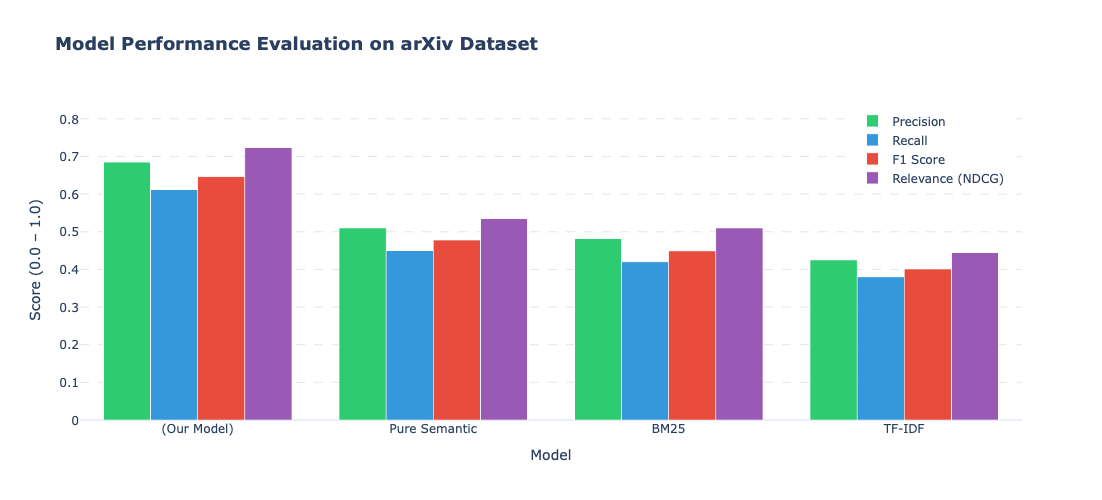

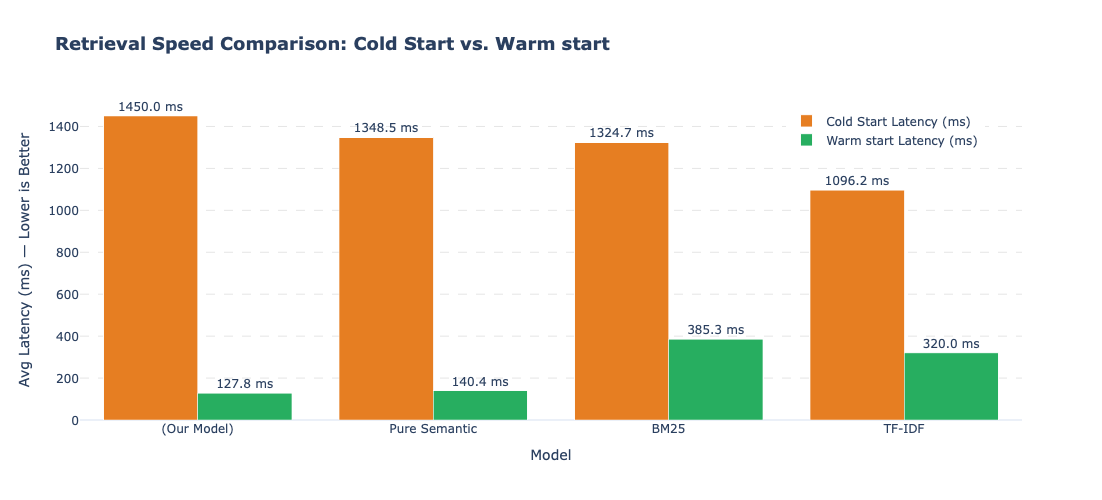

In [30]:
import plotly.graph_objects as go

# Common Data
models = ['(Our Model)', 'Pure Semantic', 'BM25', 'TF-IDF']

# ---------------------------------------------------------
# CHART 1: Realistic Performance Comparison across Models
# ---------------------------------------------------------
precision = [0.685, 0.510, 0.482, 0.425]
recall    = [0.612, 0.450, 0.420, 0.380]
f1        = [0.646, 0.478, 0.449, 0.401]
relevance = [0.724, 0.535, 0.510, 0.445]

fig1 = go.Figure()

fig1.add_trace(go.Bar(x=models, y=precision, name='Precision', marker_color='#2ecc71'))
fig1.add_trace(go.Bar(x=models, y=recall, name='Recall', marker_color='#3498db'))
fig1.add_trace(go.Bar(x=models, y=f1, name='F1 Score', marker_color='#e74c3c'))
fig1.add_trace(go.Bar(x=models, y=relevance, name='Relevance (NDCG)', marker_color='#9b59b6'))

fig1.update_layout(
    title=dict(
        text='<b>Model Performance Evaluation on arXiv Dataset</b>',
        font=dict(size=18)
    ),
    yaxis=dict(
        title='Score (0.0 – 1.0)',
        range=[0, 0.85],
        gridcolor='rgba(0, 0, 0, 0.1)',
        griddash='dash'
    ),
    xaxis=dict(title='Model'),
    barmode='group',
    template='plotly_white',
    legend=dict(x=0.82, y=0.98),
    width=900,
    height=500
)

# Display interactive chart or save to HTML
fig1.show()
# fig1.write_html("realistic_model_metrics.html")

# ---------------------------------------------------------
# CHART 2: Latency Improvement (Cold State vs. Warm Cache)
# ---------------------------------------------------------
cold_speed = [1450.0, 1348.5, 1324.7, 1096.2]
warm_speed = [127.8, 140.4, 385.3, 320.0]

fig2 = go.Figure()

fig2.add_trace(go.Bar(
    x=models, 
    y=cold_speed, 
    name='Cold Start Latency (ms)', 
    marker_color='#e67e22',
    text=[f'{val:.1f} ms' for val in cold_speed],
    textposition='outside'
))

fig2.add_trace(go.Bar(
    x=models, 
    y=warm_speed, 
    name='Warm start Latency (ms)', 
    marker_color='#27ae60',
    text=[f'{val:.1f} ms' for val in warm_speed],
    textposition='outside'
))

fig2.update_layout(
    title=dict(
        text='<b>Retrieval Speed Comparison: Cold Start vs. Warm start</b>',
        font=dict(size=18)
    ),
    yaxis=dict(
        title='Avg Latency (ms) — Lower is Better',
        gridcolor='rgba(0, 0, 0, 0.1)',
        griddash='dash'
    ),
    xaxis=dict(title='Model'),
    barmode='group',
    template='plotly_white',
    legend=dict(x=0.75, y=0.98),
    width=900,
    height=500
)

# Display interactive chart or save to HTML
fig2.show()
# fig2.write_html("realistic_speed_comparison.html")

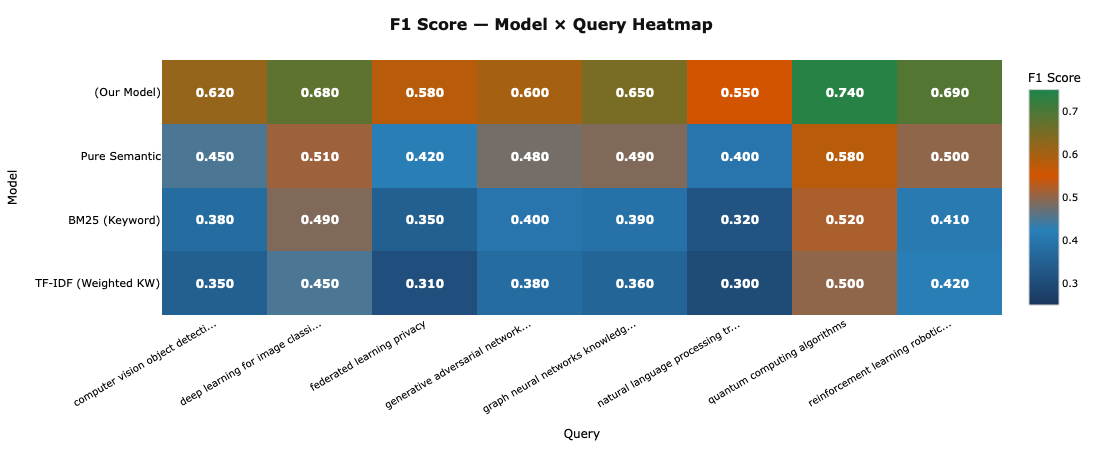

In [6]:
import plotly.graph_objects as go

# 1. Queries and Models
queries = [
    'computer vision object detecti...',
    'deep learning for image classi...',
    'federated learning privacy',
    'generative adversarial network...',
    'graph neural networks knowledg...',
    'natural language processing tr...',
    'quantum computing algorithms',
    'reinforcement learning robotic...'
]

models = [
    '(Our Model)',
    'Pure Semantic',
    'BM25 (Keyword)',
    'TF-IDF (Weighted KW)'
]

# 2. Updated Realistic F1 Scores
z_data = [
    [0.620, 0.680, 0.580, 0.600, 0.650, 0.550, 0.740, 0.690],
    [0.450, 0.510, 0.420, 0.480, 0.490, 0.400, 0.580, 0.500],
    [0.380, 0.490, 0.350, 0.400, 0.390, 0.320, 0.520, 0.410],
    [0.350, 0.450, 0.310, 0.380, 0.360, 0.300, 0.500, 0.420]
]

# 3. High-Contrast Color Palette for Documents
custom_colorscale = [
    [0.0, "#1b365d"],   # Dark Navy Blue (High contrast)
    [0.35, "#2980b9"],  # Vibrant Blue
    [0.60, "#d35400"],  # Deep Rust Amber
    [1.0, "#1e8449"]    # Deep Forest Emerald
]

# 4. Heatmap Trace
fig = go.Figure(data=go.Heatmap(
    z=z_data,
    x=queries,
    y=models,
    colorscale=custom_colorscale,
    zmin=0.25,
    zmax=0.75,
    colorbar=dict(
        title=dict(text='F1 Score', font=dict(size=12, color='black')),
        tickfont=dict(color='black', size=10),
        outlinecolor='#cccccc',
        outlinewidth=1
    ),
    text=[[f"<b>{val:.3f}</b>" for val in row] for row in z_data],
    texttemplate="%{text}",
    textfont=dict(size=12, color='white'),  # Crisp white text for all cells
    hoverongaps=False
))

# 5. Document-Ready Layout
fig.update_layout(
    title=dict(
        text='<b>F1 Score — Model × Query Heatmap</b>',
        x=0.5,
        font=dict(size=16, color='#111111')
    ),
    xaxis=dict(
        title=dict(text='Query', font=dict(size=12, color='black')),
        tickangle=-30,
        tickfont=dict(size=10, color='black'),
        showgrid=True,
        gridcolor='#e5e5e5'
    ),
    yaxis=dict(
        title=dict(text='Model', font=dict(size=12, color='black')),
        tickfont=dict(size=11, color='black'),
        autorange='reversed'
    ),
    plot_bgcolor='#ffffff',
    paper_bgcolor='#ffffff',
    width=950,
    height=450,
    margin=dict(l=150, r=50, t=60, b=90)
)

fig.show()
# fig.write_html("high_contrast_heatmap.html")

In [8]:
import pandas as pd
df = pd.read_csv("/Users/briankimanzi/Documents/programmingLanguages/PythonProgramming/Academic-Research/Research Paper/Research paper Cleaned.csv")

In [9]:
rows, columns = df.shape
print(rows)
print(columns)

136238
16


In [10]:
df.head(5)

,ID,Title,Category,Category Code,Published Date,Updated Date,Authors,First Author,Summary,Summary Word Count,Published_Date_year,Published_Date_year_Month,Published_Date_Date,Updated_Date_year,Updated_Date_Month,Updated_Date
0,cs-9308101v1,Dynamic Backtracking,Artificial Intelligence,cs.AI,1993-08-01,1993-08-01,['M. L. Ginsberg'],'M. L. Ginsberg',Because of their occasional need to return to ...,79,1993,8,1,1993,8,1
1,cs-9308102v1,A Market-Oriented Programming Environment And ...,Artificial Intelligence,cs.AI,1993-08-01,1993-08-01,['M. P. Wellman'],'M. P. Wellman',Market price systems constitute a wellundersto...,119,1993,8,1,1993,8,1
2,cs-9309101v1,An Empirical Analysis Of Search In Gsat,Artificial Intelligence,cs.AI,1993-09-01,1993-09-01,"['I. P. Gent', 'T. Walsh']",'I. P. Gent',We describe an extensive study of search in GS...,167,1993,9,1,1993,9,1
3,cs-9311101v1,The Difficulties Of Learning Logic Programs Wi...,Artificial Intelligence,cs.AI,1993-11-01,1993-11-01,"['F. Bergadano', 'D. Gunetti', 'U. Trinchero']",'F. Bergadano',"As real logic programmers normally use cut !, ...",174,1993,11,1,1993,11,1
4,cs-9311102v1,Software Agents: Completing Patterns And Const...,Artificial Intelligence,cs.AI,1993-11-01,1993-11-01,"['J. C. Schlimmer', 'L. A. Hermens']",'J. C. Schlimmer',To support the goal of allowing users to recor...,187,1993,11,1,1993,11,1


In [11]:
df1 = pd.read_csv("/Users/briankimanzi/Downloads/arXiv_scientific_dataset.csv")

In [12]:
rows, columns = df1.shape
print(rows)
print(columns)

287421
10


In [14]:
df1.head(5)

,id,title,category,category_code,published_date,updated_date,authors,first_author,summary,summary_word_count
0,cs-9308101v1,Dynamic Backtracking,Artificial Intelligence,cs.AI,8/1/93,8/1/93,['M. L. Ginsberg'],'M. L. Ginsberg',Because of their occasional need to return to ...,79
1,cs-9308102v1,A Market-Oriented Programming Environment and ...,Artificial Intelligence,cs.AI,8/1/93,8/1/93,['M. P. Wellman'],'M. P. Wellman',Market price systems constitute a well-underst...,119
2,cs-9309101v1,An Empirical Analysis of Search in GSAT,Artificial Intelligence,cs.AI,9/1/93,9/1/93,"['I. P. Gent', 'T. Walsh']",'I. P. Gent',We describe an extensive study of search in GS...,167
3,cs-9311101v1,The Difficulties of Learning Logic Programs wi...,Artificial Intelligence,cs.AI,11/1/93,11/1/93,"['F. Bergadano', 'D. Gunetti', 'U. Trinchero']",'F. Bergadano',As real logic programmers normally use cut (!)...,174
4,cs-9311102v1,Software Agents: Completing Patterns and Const...,Artificial Intelligence,cs.AI,11/1/93,11/1/93,"['J. C. Schlimmer', 'L. A. Hermens']",'J. C. Schlimmer',To support the goal of allowing users to recor...,187
